In [1]:
import torch
!pip install deepinv
import os
from torch.utils.data import Dataset, DataLoader


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.ve

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [ ]:
PT_PATH = "/content/drive/MyDrive/multiscale diffusion/data/multiscale_unbiased_vs_biased.pt"
obj = torch.load(PT_PATH, map_location="cpu")
print(obj.keys())
for k in ["unbiased", "biased"]:
    v = obj[k]
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))


dict_keys(['config', 'unbiased', 'biased'])
unbiased <class 'dict'> None None
biased <class 'dict'> None None


In [ ]:
obj = torch.load(PT_PATH, map_location="cpu")

for split in ["unbiased", "biased"]:
    d = obj[split]
    print("\n===", split, "===")
    print("type:", type(d))
    print("keys:", list(d.keys()))

    # print shapes for any tensor values
    for k, v in d.items():
        if torch.is_tensor(v):
            print(f"  {k}: tensor {tuple(v.shape)} {v.dtype}")



=== unbiased ===
type: <class 'dict'>
keys: ['combined', 'coarse', 'fine', 'normalization']
  combined: tensor (10000, 128, 128) torch.float32
  coarse: tensor (10000, 128, 128) torch.float32
  fine: tensor (10000, 128, 128) torch.float32

=== biased ===
type: <class 'dict'>
keys: ['combined', 'coarse', 'fine', 'normalization', 'combined_biased', 'bias_meta']
  combined: tensor (10000, 128, 128) torch.float32
  coarse: tensor (10000, 128, 128) torch.float32
  fine: tensor (10000, 128, 128) torch.float32
  combined_biased: tensor (10000, 128, 128) torch.float32


In [ ]:

# pick one:
x_unbiased = obj["unbiased"]["combined"]            # [N,H,W]
x_biased   = obj["biased"]["combined_biased"]       # [N,H,W]

# choose what to train on (biased)
x = x_biased

# make [N,1,H,W]
x = x.float().unsqueeze(1)
print("train tensor:", x.shape, x.dtype)  # (10000,1,128,128)


train tensor: torch.Size([10000, 1, 128, 128]) torch.float32


In [ ]:
from torch.utils.data import Dataset, DataLoader

class TensorDataset(torch.utils.data.Dataset):
    def __init__(self, tensor): self.tensor = tensor
    def __len__(self): return self.tensor.shape[0]
    def __getitem__(self, i): return self.tensor[i]

batch_size = 16  # 128x128 on DiffUNet: 16 is a decent starting point
train_loader = DataLoader(
    TensorDataset(x),
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)


In [ ]:

!pip install deepinv
import deepinv
import torch
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = deepinv.models.DiffUNet(in_channels=1, out_channels=1, pretrained=None).to(device)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.p = 0.0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mse = deepinv.loss.MSE(reduction="mean")

beta_start, beta_end = 1e-4, 0.02
timesteps = 100
betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Additional parameters needed for sampling
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]])
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

use_amp = (device == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# Create checkpoint directory
os.makedirs("/content/checkpoints", exist_ok=True)

# Sampling function
@torch.no_grad()
def sample_images(model, n_samples=16, img_size=(128, 128)):
    model.eval()
    # Start from pure noise
    x_t = torch.randn(n_samples, 1, *img_size, device=device)

    # Reverse diffusion process
    for t_idx in reversed(range(timesteps)):
        t = torch.full((n_samples,), t_idx, device=device, dtype=torch.long)

        # Predict noise
        eps_pred = model(x_t, t, type_t="timestep")

        # Compute x_{t-1}
        alpha_t = alphas[t_idx]
        alpha_cumprod_t = alphas_cumprod[t_idx]
        beta_t = betas[t_idx]

        # Mean of reverse process
        mean = sqrt_recip_alphas[t_idx] * (
            x_t - beta_t / sqrt_one_minus_alphas_cumprod[t_idx] * eps_pred
        )

        if t_idx > 0:
            noise = torch.randn_like(x_t)
            variance = posterior_variance[t_idx]
            x_t = mean + torch.sqrt(variance) * noise
        else:
            x_t = mean

    return x_t

# Compute nearest neighbor distance to training set
@torch.no_grad()
def compute_memorization_metrics(generated, training_data, n_check=16, train_sub=1000):
    gen = generated[:n_check].to(device).flatten(1)
    train = training_data[:train_sub].to(device).flatten(1)

    gen2 = (gen**2).sum(dim=1, keepdim=True)
    tr2  = (train**2).sum(dim=1).unsqueeze(0)
    d2 = gen2 + tr2 - 2.0 * (gen @ train.t())
    d2 = torch.clamp(d2, min=0.0)
    min_d = torch.sqrt(d2.min(dim=1).values)

    return {
        'mean_nn_dist': min_d.mean().item(),
        'min_nn_dist': min_d.min().item(),
        'max_nn_dist': min_d.max().item()
    }

epochs = 100
for epoch in range(epochs):
    model.train()
    running = 0.0
    for i, imgs in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)  # [B,1,128,128]
        noise = torch.randn_like(imgs)
        t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
        x_t = sqrt_alphas_cumprod[t, None, None, None] * imgs + \
              sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            eps_hat = model(x_t, t, type_t="timestep")
            loss = mse(eps_hat, noise).mean()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item()
        if i % 200 == 0:
            print(f"epoch {epoch} iter {i}/{len(train_loader)} loss {loss.item():.4f}")

    avg_loss = running/len(train_loader)
    print(f"epoch {epoch} avg loss {avg_loss:.4f}")

    # Evaluation every epoch (change to epoch % 5 == 0 if you want less frequent)
    if epoch % 5 == 0:
        print(f"\n=== Sampling and evaluating epoch {epoch} ===")

        # Generate samples
        samples = sample_images(model, n_samples=16)

        # Compute memorization metrics
        metrics = compute_memorization_metrics(samples, x, n_check=16)
        print(f"Memorization metrics:")
        print(f"  Mean NN distance: {metrics['mean_nn_dist']:.4f}")
        print(f"  Min NN distance:  {metrics['min_nn_dist']:.4f}")
        print(f"  Max NN distance:  {metrics['max_nn_dist']:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'memorization_metrics': metrics,
            'samples': samples.cpu(),
        }
        torch.save(checkpoint, f"/content/checkpoints/diffusion_epoch_{epoch}.pt")
        print(f"Checkpoint saved to /content/checkpoints/diffusion_epoch_{epoch}.pt\n")

print("\nTraining complete!")

device: cuda


/tmp/ipython-input-1307815972.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-1307815972.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch 0 iter 0/625 loss 0.9991
epoch 0 iter 200/625 loss 0.2103
epoch 0 iter 400/625 loss 0.0879
epoch 0 iter 600/625 loss 0.1409
epoch 0 avg loss 0.1284
epoch 1 iter 0/625 loss 0.1174
epoch 1 iter 200/625 loss 0.0760
epoch 1 iter 400/625 loss 0.0420
epoch 1 iter 600/625 loss 0.0961
epoch 1 avg loss 0.0926

=== Sampling and evaluating epoch 1 ===
Memorization metrics:
  Mean NN distance: 68.8658
  Min NN distance:  67.0189
  Max NN distance:  70.7001
Checkpoint saved to /content/checkpoints/diffusion_epoch_1.pt

epoch 2 iter 0/625 loss 0.0606
epoch 2 iter 200/625 loss 0.0438
epoch 2 iter 400/625 loss 0.0557
epoch 2 iter 600/625 loss 0.0775
epoch 2 avg loss 0.0926

=== Sampling and evaluating epoch 2 ===
Memorization metrics:
  Mean NN distance: 69.4055
  Min NN distance:  66.8958
  Max NN distance:  73.1015
Checkpoint saved to /content/checkpoints/diffusion_epoch_2.pt

epoch 3 iter 0/625 loss 0.0848


In [ ]:
import glob, os

ckpts = sorted(glob.glob("/content/checkpoints/diffusion_epoch_*.pt"))
print("Found", len(ckpts), "checkpoints")
ckpts[:5], ckpts[-1]


Found 5 checkpoints


(['/content/checkpoints/diffusion_epoch_0.pt',
  '/content/checkpoints/diffusion_epoch_1.pt',
  '/content/checkpoints/diffusion_epoch_2.pt',
  '/content/checkpoints/diffusion_epoch_3.pt',
  '/content/checkpoints/diffusion_epoch_4.pt'],
 '/content/checkpoints/diffusion_epoch_4.pt')

epoch: 4
loss: 0.09055158309340477
metrics: {'mean_nn_dist': 69.09446716308594, 'min_nn_dist': 66.83460998535156, 'max_nn_dist': 70.82565307617188}


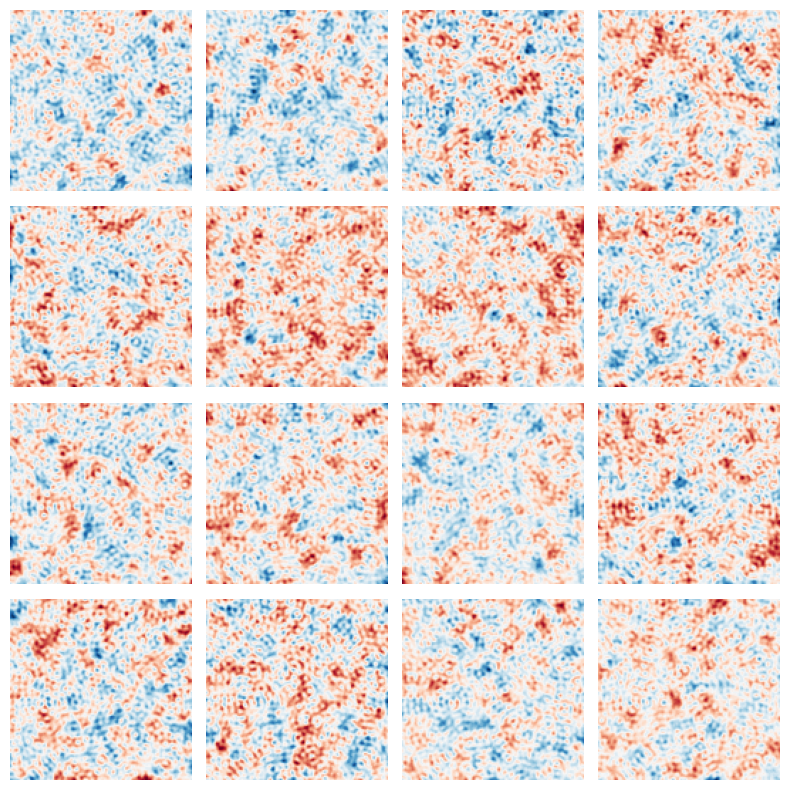

In [ ]:
import torch
import matplotlib.pyplot as plt

ckpt_path = ckpts[-1]  # pick whichever
ckpt = torch.load(ckpt_path, map_location="cpu")

print("epoch:", ckpt["epoch"])
print("loss:", ckpt["loss"])
print("metrics:", ckpt["memorization_metrics"])

samples = ckpt["samples"]  # [N,1,128,128] on CPU
n = min(samples.shape[0], 16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(samples[i,0].numpy(), cmap="RdBu")
    ax.axis("off")
plt.tight_layout()
plt.show()


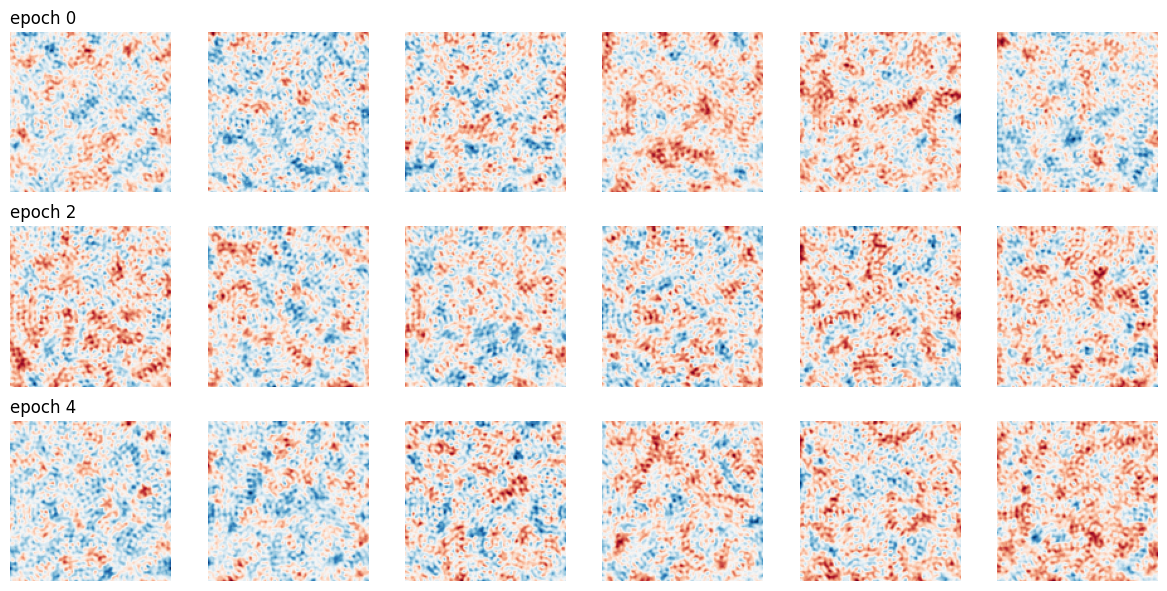

In [ ]:
import numpy as np

pick = [ckpts[0], ckpts[len(ckpts)//2], ckpts[-1]]  # early/mid/late
fig, axes = plt.subplots(len(pick), 6, figsize=(12, 2*len(pick)))

for r, p in enumerate(pick):
    ck = torch.load(p, map_location="cpu")
    s = ck["samples"][:6]
    for c in range(6):
        axes[r, c].imshow(s[c,0].numpy(), cmap="RdBu")
        axes[r, c].axis("off")
    axes[r,0].set_title(f"epoch {ck['epoch']}", loc="left")

plt.tight_layout()
plt.show()


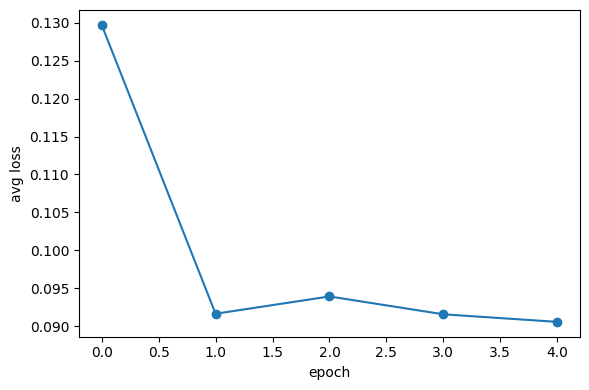

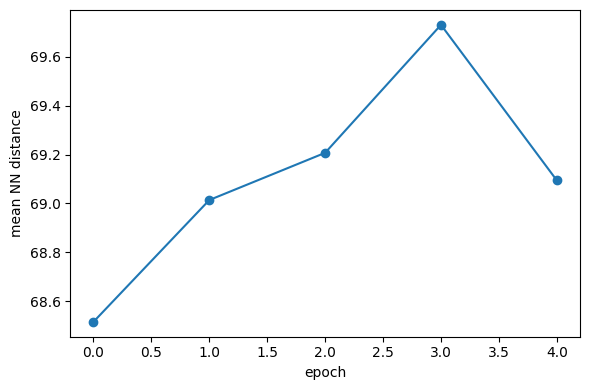

In [ ]:
epochs, losses, mean_nn = [], [], []

for p in ckpts:
    ck = torch.load(p, map_location="cpu")
    epochs.append(ck["epoch"])
    losses.append(float(ck["loss"]))
    mean_nn.append(float(ck["memorization_metrics"]["mean_nn_dist"]))

plt.figure(figsize=(6,4))
plt.plot(epochs, losses, marker="o")
plt.xlabel("epoch")
plt.ylabel("avg loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, mean_nn, marker="o")
plt.xlabel("epoch")
plt.ylabel("mean NN distance")
plt.tight_layout()
plt.show()
